In [1]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# ─── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("✅ All libraries imported successfully!")
print(f"   NumPy  {np.__version__} | Pandas {pd.__version__}")

✅ All libraries imported successfully!
   NumPy  2.3.5 | Pandas 2.3.3


In [2]:
# ─── Load the Titanic dataset (built-in via seaborn OR from CSV) ──────────────
df = sns.load_dataset('titanic')

# Standardise column names to match Kaggle convention
df = df.rename(columns={
    'pclass': 'Pclass', 'sex': 'Sex', 'age': 'Age',
    'sibsp': 'SibSp', 'parch': 'Parch', 'fare': 'Fare',
    'embarked': 'Embarked', 'survived': 'Survived'
})

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(10)

Dataset shape: (891, 15)
Rows: 891  |  Columns: 15


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
print("=" * 55)
print("DATASET INFORMATION")
print("=" * 55)
df.info()


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Survived     891 non-null    int64   
 1   Pclass       891 non-null    int64   
 2   Sex          891 non-null    object  
 3   Age          714 non-null    float64 
 4   SibSp        891 non-null    int64   
 5   Parch        891 non-null    int64   
 6   Fare         891 non-null    float64 
 7   Embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe(include='all').T.style.background_gradient(cmap='Blues')


DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,891.000000,nan,nan,nan,0.383838,0.486592,0.000000,0.000000,0.000000,1.000000,1.000000
Pclass,891.000000,nan,nan,nan,2.308642,0.836071,1.000000,2.000000,3.000000,3.000000,3.000000
Sex,891,2,male,577,nan,nan,nan,nan,nan,nan,nan
Age,714.000000,nan,nan,nan,29.699118,14.526497,0.420000,20.125000,28.000000,38.000000,80.000000
SibSp,891.000000,nan,nan,nan,0.523008,1.102743,0.000000,0.000000,0.000000,1.000000,8.000000
Parch,891.000000,nan,nan,nan,0.381594,0.806057,0.000000,0.000000,0.000000,0.000000,6.000000
Fare,891.000000,nan,nan,nan,32.204208,49.693429,0.000000,7.910400,14.454200,31.000000,512.329200
Embarked,889,3,S,644,nan,nan,nan,nan,nan,nan,nan
class,891,3,Third,491,nan,nan,nan,nan,nan,nan,nan
who,891,3,man,537,nan,nan,nan,nan,nan,nan,nan


             Missing Count  Missing %
deck                   688      77.22
Age                    177      19.87
Embarked                 2       0.22
embark_town              2       0.22


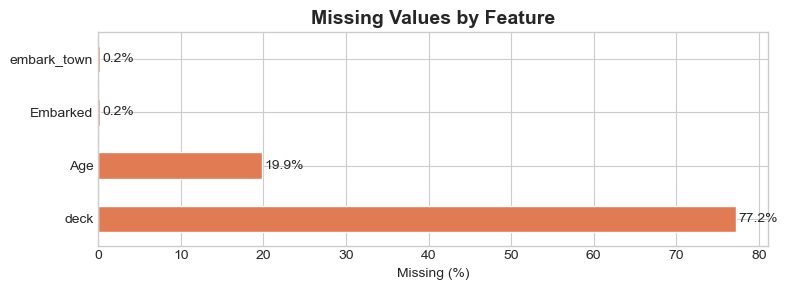

In [5]:
# ─── Calculate missing values ────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing.to_string())

# ─── Visualise missingness ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
missing['Missing %'].plot(kind='barh', ax=ax, color='#E07B54', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
# ─── Work on a clean copy ────────────────────────────────────────────────────
df_clean = df.copy()

# 1. Age  → median imputation (less sensitive to outliers than mean)
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# 2. Embarked → mode imputation (only 2 rows missing)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Drop columns with >70% missing or low analytical value
cols_to_drop = ['deck', 'embark_town', 'alive', 'who', 'adult_male',
                'alone', 'class']
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns],
              inplace=True)

# 4. Verify
remaining_missing = df_clean.isnull().sum().sum()
print(f"✅ Missing values after cleaning: {remaining_missing}")
print(f"   Shape: {df_clean.shape}")
df_clean.head()

✅ Missing values after cleaning: 0
   Shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


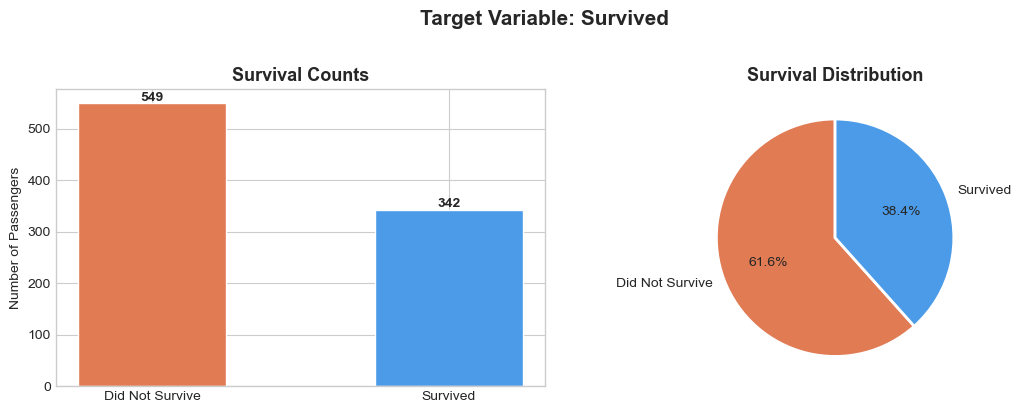

Survival rate: 38.4%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
counts = df_clean['Survived'].value_counts()
colors = ['#E07B54', '#4C9BE8']
axes[0].bar(['Did Not Survive', 'Survived'], counts.values,
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Survival Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Did Not Survive', 'Survived'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Survival Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Survived', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Survival rate: {df_clean['Survived'].mean()*100:.1f}%")


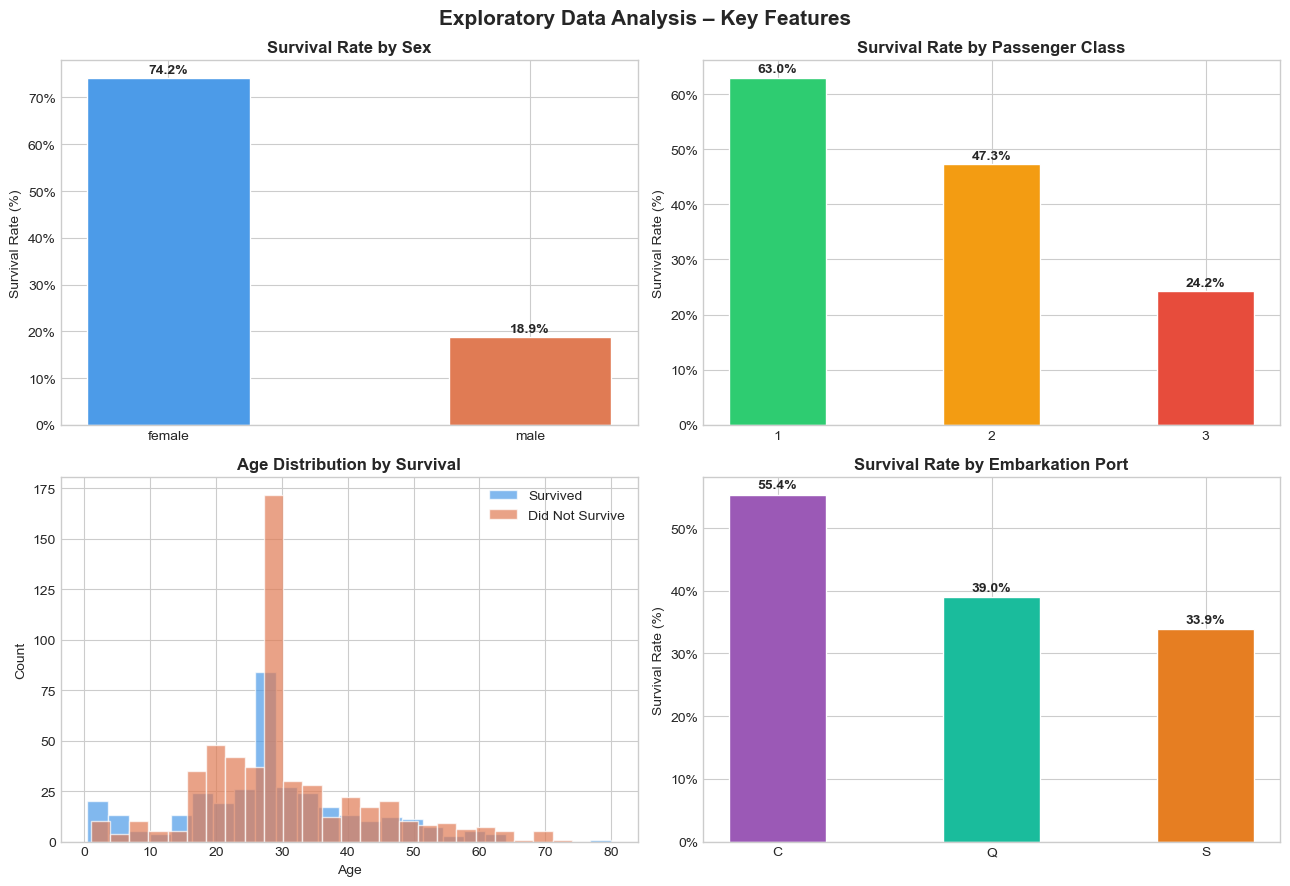

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Sex ────────────────────────────────────────────────────────────────────────
sex_surv = df_clean.groupby('Sex')['Survived'].mean().reset_index()
axes[0,0].bar(sex_surv['Sex'], sex_surv['Survived']*100,
              color=['#4C9BE8', '#E07B54'], edgecolor='white', width=0.45)
axes[0,0].set_title('Survival Rate by Sex', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Survival Rate (%)')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, row in sex_surv.iterrows():
    axes[0,0].text(i, row['Survived']*100 + 1, f"{row['Survived']*100:.1f}%",
                   ha='center', fontweight='bold')

# ── Pclass ────────────────────────────────────────────────────────────────────
pclass_surv = df_clean.groupby('Pclass')['Survived'].mean().reset_index()
axes[0,1].bar(pclass_surv['Pclass'].astype(str), pclass_surv['Survived']*100,
              color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white', width=0.45)
axes[0,1].set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Survival Rate (%)')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, row in pclass_surv.iterrows():
    axes[0,1].text(i, row['Survived']*100 + 1, f"{row['Survived']*100:.1f}%",
                   ha='center', fontweight='bold')

# ── Age distribution ──────────────────────────────────────────────────────────
df_clean[df_clean['Survived']==1]['Age'].hist(ax=axes[1,0], bins=25,
    alpha=0.7, color='#4C9BE8', label='Survived', edgecolor='white')
df_clean[df_clean['Survived']==0]['Age'].hist(ax=axes[1,0], bins=25,
    alpha=0.7, color='#E07B54', label='Did Not Survive', edgecolor='white')
axes[1,0].set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# ── Embarked ──────────────────────────────────────────────────────────────────
emb_surv = df_clean.groupby('Embarked')['Survived'].mean().reset_index()
axes[1,1].bar(emb_surv['Embarked'], emb_surv['Survived']*100,
              color=['#9b59b6','#1abc9c','#e67e22'], edgecolor='white', width=0.45)
axes[1,1].set_title('Survival Rate by Embarkation Port', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Survival Rate (%)')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, row in emb_surv.iterrows():
    axes[1,1].text(i, row['Survived']*100 + 1, f"{row['Survived']*100:.1f}%",
                   ha='center', fontweight='bold')

plt.suptitle('Exploratory Data Analysis – Key Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


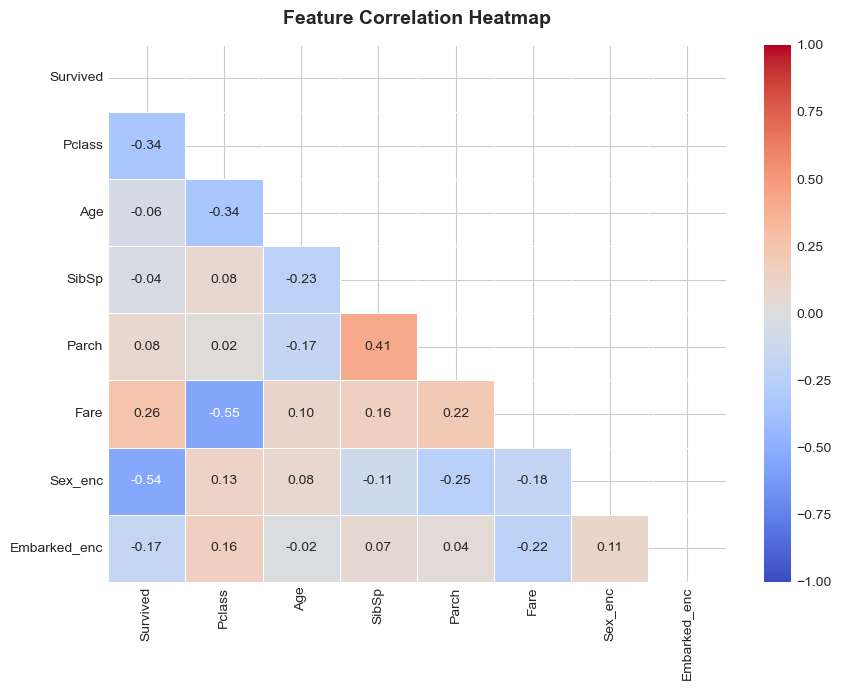

Key correlations with Survived:
Survived        1.000000
Fare            0.257307
Parch           0.081629
SibSp          -0.035322
Age            -0.064910
Embarked_enc   -0.167675
Pclass         -0.338481
Sex_enc        -0.543351


In [9]:
# ─── Encode categoricals for correlation ────────────────────────────────────
df_corr = df_clean.copy()
df_corr['Sex_enc'] = (df_corr['Sex'] == 'male').astype(int)
df_corr['Embarked_enc'] = LabelEncoder().fit_transform(df_corr['Embarked'])
num_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare','Sex_enc','Embarked_enc']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_corr[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("Key correlations with Survived:")
print(corr['Survived'].sort_values(ascending=False).to_string())


In [10]:
df_fe = df_clean.copy()

# 1. Family size
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1

# 2. Is alone
df_fe['IsAlone'] = (df_fe['FamilySize'] == 1).astype(int)

# 3. Age bands
df_fe['AgeBand'] = pd.cut(df_fe['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior'])

# 4. Fare bands (log transform to reduce skew)
df_fe['FareLog'] = np.log1p(df_fe['Fare'])

# 5. Sex × Pclass interaction
df_fe['Sex_Pclass'] = df_fe['Sex'].map({'male': 'M', 'female': 'F'}) + df_fe['Pclass'].astype(str)

print("New features created:")
new_feat_cols = ['FamilySize', 'IsAlone', 'AgeBand', 'FareLog', 'Sex_Pclass']
print(df_fe[new_feat_cols].head(10).to_string())


New features created:
   FamilySize  IsAlone    AgeBand   FareLog Sex_Pclass
0           2        0      Adult  2.110213         M3
1           2        0  MiddleAge  4.280593         F1
2           1        1      Adult  2.188856         F3
3           2        0      Adult  3.990834         F1
4           1        1      Adult  2.202765         M3
5           1        1      Adult  2.246893         M3
6           1        1  MiddleAge  3.967694         M1
7           5        0      Child  3.094446         M3
8           3        0      Adult  2.495954         F3
9           2        0       Teen  3.436268         F2


In [11]:
df_model = df_fe.copy()

# ─── Encode categorical columns ───────────────────────────────────────────────
le = LabelEncoder()
df_model['Sex']      = le.fit_transform(df_model['Sex'])
df_model['Embarked'] = le.fit_transform(df_model['Embarked'])
df_model['AgeBand']  = le.fit_transform(df_model['AgeBand'].astype(str))
df_model['Sex_Pclass'] = le.fit_transform(df_model['Sex_Pclass'])

# ─── Select final features ────────────────────────────────────────────────────
FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
            'FamilySize', 'IsAlone', 'AgeBand', 'FareLog', 'Sex_Pclass']

X = df_model[FEATURES]
y = df_model['Survived']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape       : {y.shape}")
print(f"Class balance      : {y.value_counts().to_dict()}")


Feature matrix shape: (891, 12)
Target shape       : (891,)
Class balance      : {0: 549, 1: 342}


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Train survival: {y_train.mean()*100:.1f}%")
print(f"Test  survival: {y_test.mean()*100:.1f}%")

Training set  : 712 samples
Test set      : 179 samples
Train survival: 38.3%
Test  survival: 38.5%


In [13]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    results[name] = {'cv_mean': scores.mean(), 'cv_std': scores.std()}
    model.fit(X_train_sc, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_sc))
    results[name]['test_acc'] = test_acc
    print(f"{name:<25}  CV: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%  "
          f"|  Test: {test_acc*100:.2f}%")


Logistic Regression        CV: 79.08% ± 2.30%  |  Test: 79.89%
Decision Tree              CV: 78.09% ± 2.86%  |  Test: 81.01%
Random Forest              CV: 80.61% ± 1.69%  |  Test: 80.45%
Gradient Boosting          CV: 81.60% ± 1.97%  |  Test: 79.89%
SVM                        CV: 82.58% ± 1.63%  |  Test: 82.68%
KNN                        CV: 79.78% ± 2.29%  |  Test: 78.21%


In [16]:
# ─── Tune Random Forest (typically best on this dataset) ─────────────────────
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth'   : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

grid_search.fit(X_train_sc, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_*100:.2f}%")
print(f"Test Accuracy   : {accuracy_score(y_test, best_rf.predict(X_test_sc))*100:.2f}%")


Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Best CV Accuracy: 82.60%
Test Accuracy   : 80.45%


In [17]:
y_pred      = best_rf.predict(X_test_sc)
y_pred_prob = best_rf.predict_proba(X_test_sc)[:, 1]

print("=" * 55)
print("CLASSIFICATION REPORT – Random Forest (Tuned)")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Did Not Survive', 'Survived']))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score : {roc_auc:.4f}")


CLASSIFICATION REPORT – Random Forest (Tuned)
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.90      0.85       110
       Survived       0.80      0.65      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.78       179
   weighted avg       0.80      0.80      0.80       179

ROC-AUC Score : 0.8312


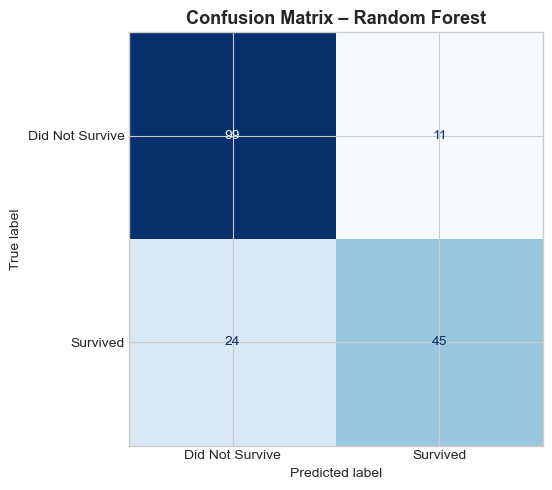

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

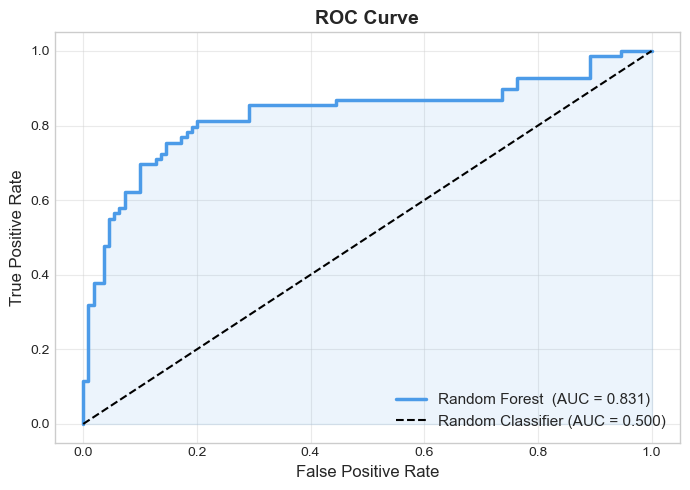

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#4C9BE8', lw=2.5,
        label=f'Random Forest  (AUC = {roc_auc:.3f})')
ax.plot([0,1], [0,1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.10, color='#4C9BE8')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

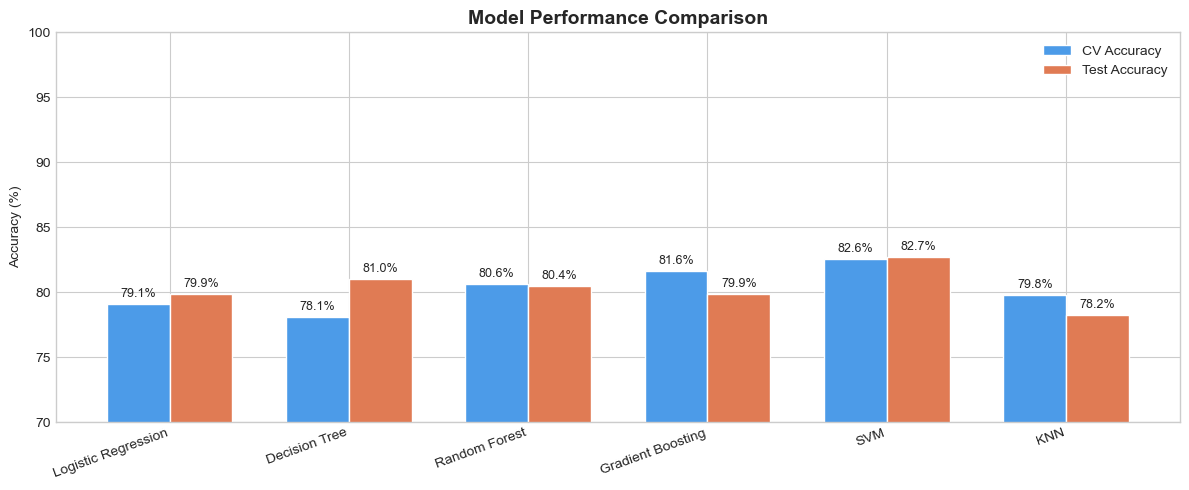

In [20]:
names  = list(results.keys())
cv_acc = [results[n]['cv_mean']*100  for n in names]
te_acc = [results[n]['test_acc']*100 for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, cv_acc, w, label='CV Accuracy', color='#4C9BE8', edgecolor='white')
bars2 = ax.bar(x + w/2, te_acc, w, label='Test Accuracy', color='#E07B54', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(70, 100)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

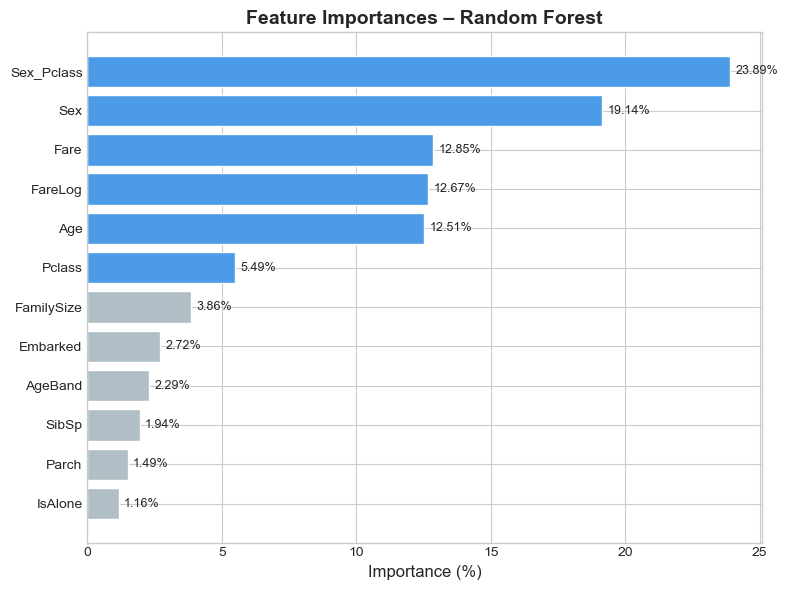

In [21]:
importances = best_rf.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C9BE8' if v > 0.05 else '#B0BEC5' for v in fi_df['Importance']]
ax.barh(fi_df['Feature'], fi_df['Importance'] * 100, color=colors, edgecolor='white')
ax.set_xlabel('Importance (%)', fontsize=12)
ax.set_title('Feature Importances – Random Forest', fontsize=14, fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()